# CE322 Pattern Recognition — TikTok Project
## Notebook 2: Feature Engineering & Label Creation

This notebook builds the full feature matrix from raw fields and defines the engagement-based class labels used in supervised learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/tiktok_clean.csv', parse_dates=['create_time_utc', 'collected_at_utc'])
print(f"Loaded: {df.shape}")
df.head(3)

Loaded: (55160, 15)


,video_id,author_username,author_category,description,create_time_utc,duration_seconds,hashtag_count,engagement_rate,is_weekend,digg_count,comment_count,share_count,play_count,source_target,collected_at_utc
0,7630058041693474056,melihagbi,entertainment,aristo şaşırttın be - Gün 230/365,2026-04-18 11:22:09+00:00,53.0,0,0.044188,1,1646,12,30,38200,user:melihagbi,2026-04-18 23:19:36.271637+00:00
1,7629760934583536914,melihagbi,entertainment,Selanik’te bi Osmanlı kalesi Gün 229/365,2026-04-17 16:09:15+00:00,38.0,0,0.036502,0,2195,20,70,62600,user:melihagbi,2026-04-18 23:19:36.271657+00:00
2,7629283124785990919,melihagbi,entertainment,çok üzgünüm,2026-04-16 09:15:05+00:00,19.0,0,0.062140,0,20500,88,229,335000,user:melihagbi,2026-04-18 23:19:36.271667+00:00


## 2.1 Temporal Features

In [2]:
# Extract temporal features from create_time_utc
df['posting_hour']   = df['create_time_utc'].dt.hour
df['day_of_week']    = df['create_time_utc'].dt.dayofweek   # 0=Monday
df['month']          = df['create_time_utc'].dt.month
df['time_gap_days']  = (df['collected_at_utc'] - df['create_time_utc']).dt.total_seconds() / 86400

# Posting period buckets
bins   = [-1, 5, 11, 17, 23]
labels = ['night', 'morning', 'afternoon', 'evening']
df['posting_period'] = pd.cut(df['posting_hour'], bins=bins, labels=labels)

print("Posting hour distribution:")
print(df['posting_hour'].value_counts().sort_index())

Posting hour distribution:
posting_hour
0      266
1      134
2      126
3      120
4      176
5      389
6      685
7     1307
8     1875
9     2346
10    2352
11    2602
12    2969
13    3450
14    5006
15    5732
16    5928
17    6054
18    4562
19    3502
20    2608
21    1574
22     869
23     528
Name: count, dtype: int64


## 2.2 Ratio Features

In [3]:
# Engagement decomposition ratios
df['like_to_play']    = df['digg_count']    / (df['play_count'] + 1)
df['comment_to_play'] = df['comment_count'] / (df['play_count'] + 1)
df['share_to_play']   = df['share_count']   / (df['play_count'] + 1)
df['like_to_comment'] = df['digg_count']    / (df['comment_count'] + 1)

print("Ratio feature stats:")
print(df[['like_to_play','comment_to_play','share_to_play']].describe())

Ratio feature stats:
       like_to_play  comment_to_play  share_to_play
count  55160.000000     55160.000000   55160.000000
mean       0.033708         0.030194       0.001789
std        0.645989         2.371823       0.025054
min        0.000000         0.000000       0.000000
25%        0.014321         0.000109       0.000321
50%        0.023520         0.000245       0.000864
75%        0.038194         0.000588       0.001952
max      138.636364       459.000000       5.842676


## 2.3 Text Features

In [4]:
# Lightweight text features from description (no full NLP needed)
df['desc_length']     = df['description'].str.len()
df['word_count']      = df['description'].str.split().str.len().fillna(0)
df['has_description'] = (df['desc_length'] > 0).astype(int)
df['hashtag_density'] = df['hashtag_count'] / (df['word_count'] + 1)

# Detect common Turkish engagement keywords
keywords = ['keşfet', 'viral', 'trend', 'challenge', 'takip', 'beğen', 'yorum']
for kw in keywords:
    df[f'kw_{kw}'] = df['description'].str.lower().str.contains(kw, na=False).astype(int)

print("Text feature summary:")
print(df[['desc_length','word_count','hashtag_density']].describe())

Text feature summary:
        desc_length    word_count  hashtag_density
count  49459.000000  55160.000000     55160.000000
mean     153.579652     18.889068         0.250635
std      283.940129     41.314651         0.284132
min        1.000000      0.000000         0.000000
25%       37.000000      4.000000         0.000000
50%       68.000000      8.000000         0.142857
75%      126.000000     14.000000         0.444444
max     4048.000000    617.000000         3.000000


## 2.4 Log Transformations (Skewed Count Data)

In [5]:
for col in ['digg_count', 'comment_count', 'share_count', 'play_count', 'duration_seconds']:
    df[f'log_{col}'] = np.log1p(df[col])

print("Log features created.")

Log features created.


## 2.5 Categorical Encoding

In [6]:
# author_category → one-hot encoding
cat_dummies = pd.get_dummies(df['author_category'], prefix='cat')
df = pd.concat([df, cat_dummies], axis=1)

# posting_period → ordinal
period_map = {'night': 0, 'morning': 1, 'afternoon': 2, 'evening': 3}
df['posting_period_enc'] = df['posting_period'].map(period_map)

print("Category dummies:", cat_dummies.columns.tolist())

Category dummies: ['cat_business_finance', 'cat_education', 'cat_entertainment', 'cat_fashion_beauty', 'cat_fitness_health', 'cat_food_beverage', 'cat_gaming', 'cat_lifestyle', 'cat_tech', 'cat_travel']


## 2.6 Target Label Creation

**Strategy**: 3-class performance label based on `play_count` quantiles (33rd / 66th percentile).

`engagement_rate` is kept as an **input feature** — not the target — to avoid target leakage.

Low threshold  (33rd pct): 15,500
High threshold (66th pct): 118,700

Class distribution:
performance_label_str
high      18422
low       18383
medium    18355
Name: count, dtype: int64


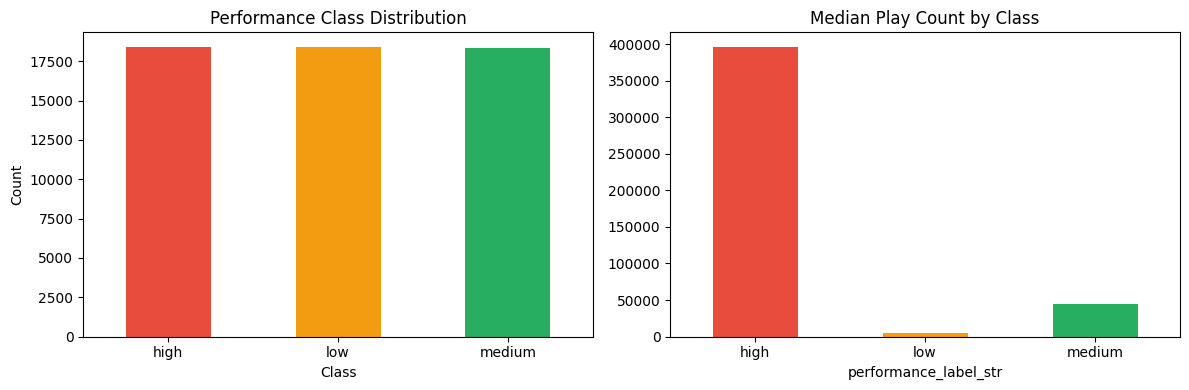

In [7]:
# 3-class label: low / medium / high based on play_count tertiles
low_thresh  = df['play_count'].quantile(0.333)
high_thresh = df['play_count'].quantile(0.666)
print(f"Low threshold  (33rd pct): {low_thresh:,.0f}")
print(f"High threshold (66th pct): {high_thresh:,.0f}")

def label_performance(x):
    if x <= low_thresh:  return 0   # low
    elif x <= high_thresh: return 1 # medium
    else: return 2                   # high

df['performance_label'] = df['play_count'].apply(label_performance)
df['performance_label_str'] = df['performance_label'].map({0:'low', 1:'medium', 2:'high'})

print("\nClass distribution:")
print(df['performance_label_str'].value_counts())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['performance_label_str'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c','#f39c12','#27ae60'])
axes[0].set_title('Performance Class Distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

df.groupby('performance_label_str')['play_count'].median().plot(kind='bar', ax=axes[1], color=['#e74c3c','#f39c12','#27ae60'])
axes[1].set_title('Median Play Count by Class')
axes[1].tick_params(rotation=0)
plt.tight_layout()
plt.savefig('../data/label_distribution.png', dpi=150)
plt.show()

## 2.7 Final Feature Matrix

In [8]:
# Define the final feature columns to use in modeling
FEATURE_COLS = [
    # Raw numeric
    'duration_seconds', 'hashtag_count', 'engagement_rate', 'is_weekend',
    # Log-transformed counts (no leakage: we predict play_count class, these are inputs)
    'log_digg_count', 'log_comment_count', 'log_share_count',
    # Ratios
    'like_to_play', 'comment_to_play', 'share_to_play', 'like_to_comment',
    # Text features
    'desc_length', 'word_count', 'has_description', 'hashtag_density',
    # Temporal
    'posting_hour', 'day_of_week', 'month', 'time_gap_days', 'posting_period_enc',
    # Category dummies
] + [c for c in df.columns if c.startswith('cat_')]

print(f"Total features: {len(FEATURE_COLS)}")
print("Features:", FEATURE_COLS)

# Save feature list for other notebooks
import json
with open('../data/feature_cols.json', 'w') as f:
    json.dump(FEATURE_COLS, f)

# Save full engineered dataset
df.to_csv('../data/tiktok_features.csv', index=False)
print("\nSaved: data/tiktok_features.csv")

Total features: 30
Features: ['duration_seconds', 'hashtag_count', 'engagement_rate', 'is_weekend', 'log_digg_count', 'log_comment_count', 'log_share_count', 'like_to_play', 'comment_to_play', 'share_to_play', 'like_to_comment', 'desc_length', 'word_count', 'has_description', 'hashtag_density', 'posting_hour', 'day_of_week', 'month', 'time_gap_days', 'posting_period_enc', 'cat_business_finance', 'cat_education', 'cat_entertainment', 'cat_fashion_beauty', 'cat_fitness_health', 'cat_food_beverage', 'cat_gaming', 'cat_lifestyle', 'cat_tech', 'cat_travel']

Saved: data/tiktok_features.csv


## 2.8 Correlation Heatmap

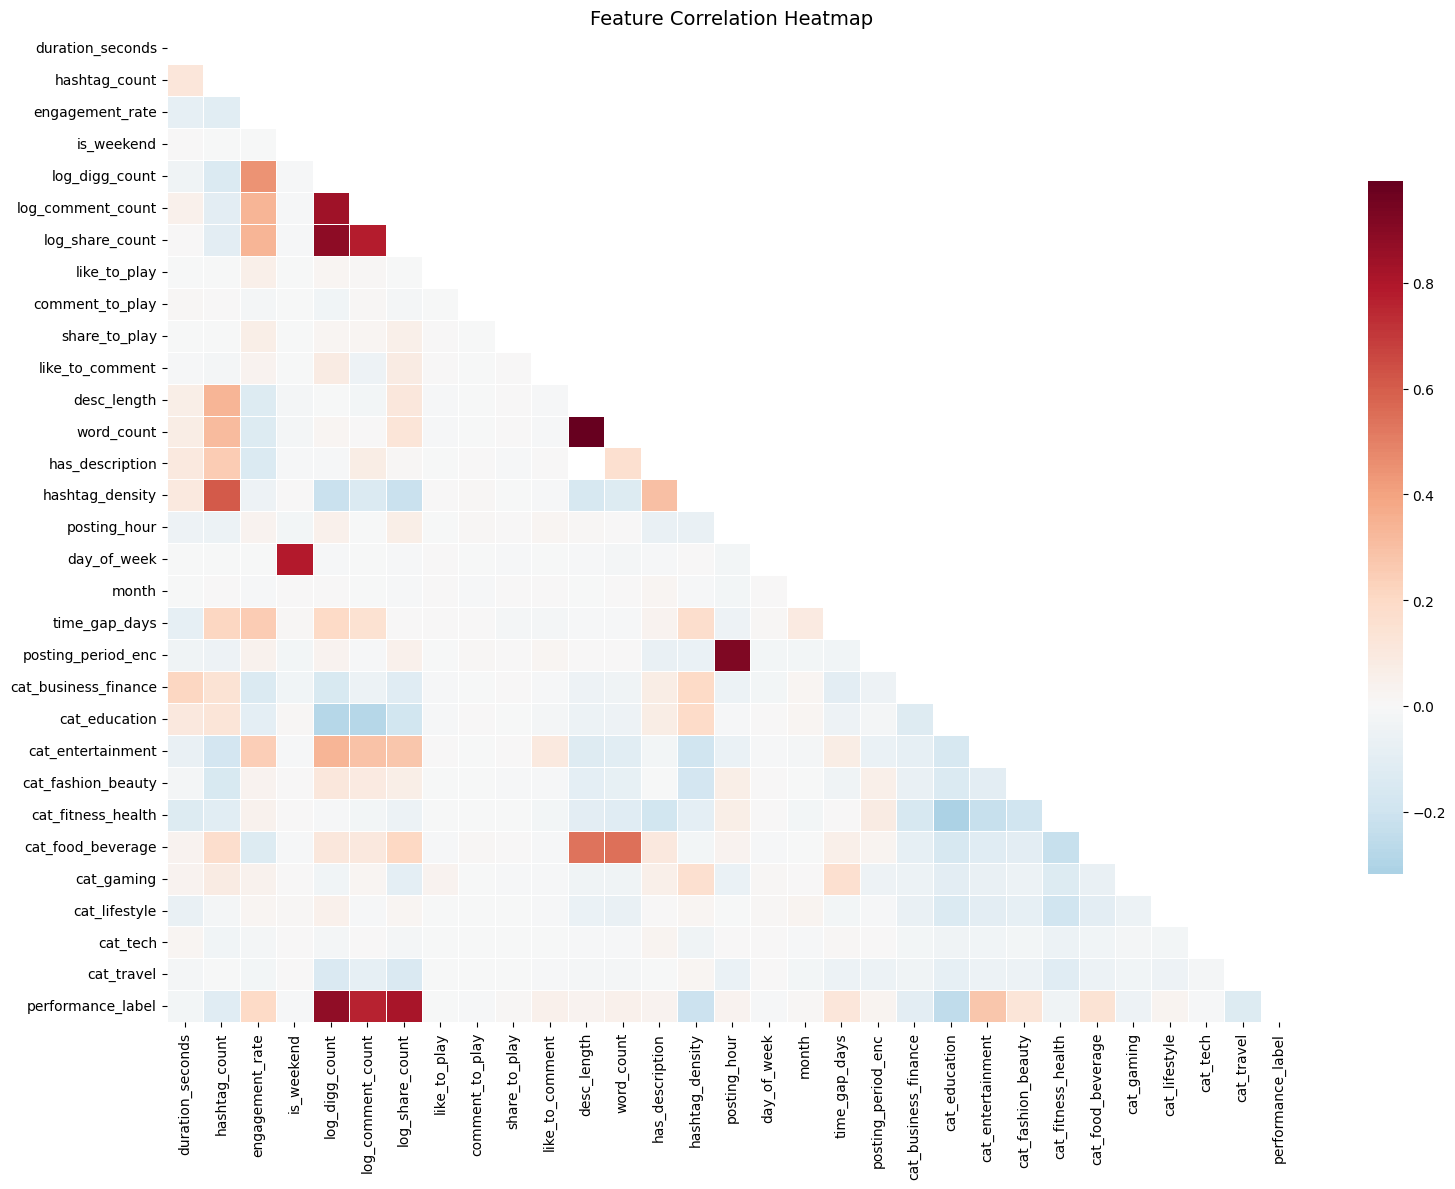

In [9]:
numeric_features = [c for c in FEATURE_COLS if c in df.columns and df[c].dtype != object]
corr = df[numeric_features + ['performance_label']].corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, annot=False,
            linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('../data/correlation_heatmap.png', dpi=150)
plt.show()